In [1]:
from pathlib import Path
import sys


here = Path.cwd()
candidates = [here] + list(here.parents)
for p in candidates:
    if (p / "Code").is_dir():
        sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Couldn't find a 'Code' folder in this project.")

import autograd.numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Code.ffnn2 import NeuralNetwork as FFNN 
from Code.scheduler import Adam, RMS_prop, Constant, Scheduler
from Code.activations import sigmoid, identity, derivate 
import pandas as pd
import seaborn as sns 




In [3]:
"""Data prep"""

def runge_function(x):
    return 1.0 / (1.0 + 25 * x**2) 

N = 100
x = np.linspace(-1, 1, N).reshape(-1, 1)
y = runge_function(x) 

# Scale data 
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42) 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

In [4]:
"""Cost functions"""

def CostOLS(pred, target):
    """Mean squared error over the batch."""
    return np.mean((pred - target) ** 2)

def dCostOLS(pred, target):
    """Derivative of MSE wrt predictions (averaged over batch)."""
    N = pred.shape[0]
    return (2.0 / N) * (pred - target)


In [5]:
"""Helper for running the comparisons etc"""

def run_comparison(optimizer, X_train, t_train, network_input_size, layer_output_sizes, **kwargs):
    # Determine activation functions based on layers count
    n_hidden_layers = len(layer_output_sizes) - 1
    
    # Sigmoid for hidden layers, Identity for output (Regression) [28]
    activation_funcs = [sigmoid] * n_hidden_layers + [identity]
    activation_ders = [derivate(f) for f in activation_funcs]
    
    # Initialize NN object

    nn = FFNN(
    network_input_size=network_input_size, 
    layer_output_sizes=tuple(layer_output_sizes),
    activation_funcs=activation_funcs,  # List/tuple of all activation functions (hidden + output) [1, 5]
    activation_ders=activation_ders,    # List/tuple of all corresponding derivatives [1, 5]
    cost_fun=CostOLS,                  # Cost function [1, 5]
    cost_der=dCostOLS, 
    seed=42
    )

    nn.reset_weights()

    # Extract common nn.fit arguments from kwargs (epochs, batches, lam) [27]
    epochs = kwargs.pop('epochs', 100)
    batches = kwargs.pop('batches', 25)
    lam = kwargs.pop('lam', 0.0)
    l1  = kwargs.pop('l1', None)          
    l2  = kwargs.pop('l2', None) 

    # Instantiate the scheduler using remaining kwargs (eta, rho, rho2, etc.)
    opt_args = {k: v for k, v in kwargs.items() if k in ("eta", "rho", "rho2", "eps", "beta1", "beta2")}
    scheduler_instance = optimizer(**opt_args)

    # Train the network
    scores = nn.fit(
        X_train, 
        t_train, 
        scheduler=scheduler_instance, 
        epochs=epochs, 
        batches=batches,
        lam=lam,
        l1=l1,
        l2=l2
    )
    return scores, nn






# Part b

In [6]:
input_nodes = X_train_scaled.shape[1] 
output_nodes = 1
batches_gd = 1
epochs_comparison = 1000 
lam = 0.0
hidden_nodes1 = 50
hidden_nodes2 = 100

# Architecture 1: One Hidden Layer (50 nodes) 
layer_sizes_1H = [hidden_nodes1, output_nodes]

# Architecture 2: Two Hidden Layers (50 and 100 nodes)
layer_sizes_2H = [hidden_nodes1, hidden_nodes2, output_nodes]

eta_base = 0.01 
rho_val = 0.9      # Recommended rho for RMSprop/Adam [6, 7]
rho2_val = 0.999   # Recommended rho2 for Adam [6, 7]


optimizers_to_sweep = {
    'GD': (Constant, {'batches': batches_gd}),
    'SGD': (Constant, {}),
    'RMS_prop': (RMS_prop, {'rho': rho_val}),
    'Adam': (Adam, {'rho': rho_val, 'rho2': rho2_val})
}
eta_vals = np.logspace(-5, -1, 5) # Sweep 6 values
epochs_sweep = 500



### Sweep hyperparameters: 

In [7]:
all_sweep_results = {}

architectures_to_sweep = {
    '1_Hidden_Layer (50)': layer_sizes_1H,
    '2_Hidden_Layers (50, 100)': layer_sizes_2H
}


# hyperparameter sweep 
for arch_name, layer_sizes in architectures_to_sweep.items():
    print(f"\n================ Sweep for {arch_name} ================")
    arch_scores = {}
    
    for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
        print(f"--- Optimizer {opt_name} ---")
        mse_scores_for_eta = []
        
        for eta in eta_vals:
            # Prepare kwargs for the current run
            current_kwargs = {'eta': eta}
            current_kwargs.update(fixed_params)
            
            # Run comparison using the defined architecture
            scores, nn = run_comparison(
                optimizer_class,
                X_train_scaled, 
                y_train,
                network_input_size=input_nodes,
                layer_output_sizes=layer_sizes,
                epochs=epochs_sweep,  
                lam=lam,
                **current_kwargs
            )
            
            y_pred_test = nn.predict(X_test_scaled) 

            # Get the final mse
            final_mse = CostOLS(y_pred_test, y_test)
            mse_scores_for_eta.append(final_mse)
            print(f"  {opt_name} (eta={eta:.1e}): MSE={final_mse:.6f}")
        
        arch_scores[opt_name] = mse_scores_for_eta

    all_sweep_results[arch_name] = arch_scores


================ Sweep for 1_Hidden_Layer (50) ================
--- Optimizer GD ---
  GD (eta=1.0e-05): MSE=0.090380
  GD (eta=1.0e-04): MSE=0.069959
  GD (eta=1.0e-03): MSE=0.069664
  GD (eta=1.0e-02): MSE=0.069186
  GD (eta=1.0e-01): MSE=0.068382
--- Optimizer SGD ---
  SGD (eta=1.0e-05): MSE=0.069618
  SGD (eta=1.0e-04): MSE=0.069443
  SGD (eta=1.0e-03): MSE=0.069209
  SGD (eta=1.0e-02): MSE=0.071939
  SGD (eta=1.0e-01): MSE=0.001389
--- Optimizer RMS_prop ---
  RMS_prop (eta=1.0e-05): MSE=0.069022
  RMS_prop (eta=1.0e-04): MSE=0.069078
  RMS_prop (eta=1.0e-03): MSE=0.015646
  RMS_prop (eta=1.0e-02): MSE=0.002204
  RMS_prop (eta=1.0e-01): MSE=0.004364
--- Optimizer Adam ---
  Adam (eta=1.0e-05): MSE=0.069245
  Adam (eta=1.0e-04): MSE=0.069243
  Adam (eta=1.0e-03): MSE=0.068034
  Adam (eta=1.0e-02): MSE=0.000463
  Adam (eta=1.0e-01): MSE=0.000289

================ Sweep for 2_Hidden_Layers (50, 100) ================
--- Optimizer GD ---
  GD (eta=1.0e-05): MSE=0.091323
  GD (eta=1.

### Visualization

<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/var/folders/yn/p45qg2hs32j6_2k0vv9s4kcw0000gn/T/ipykernel_17882/4142863516.py:15: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Learning Rate ($\eta$)')


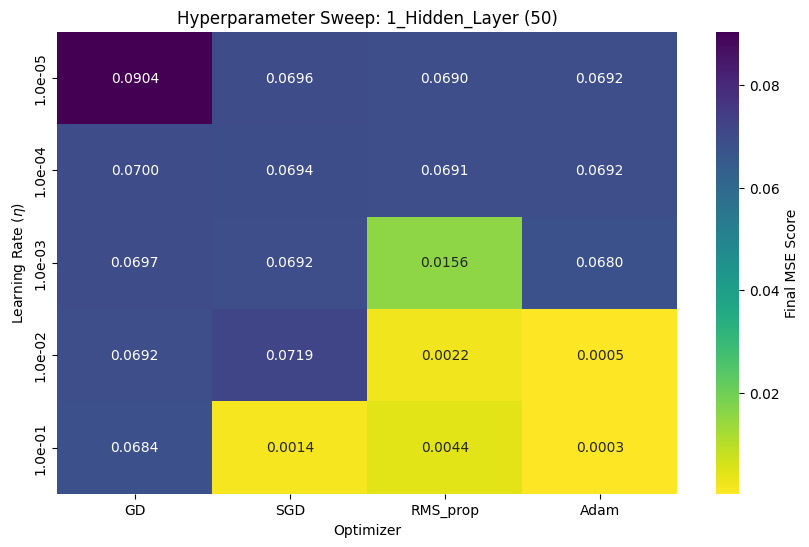

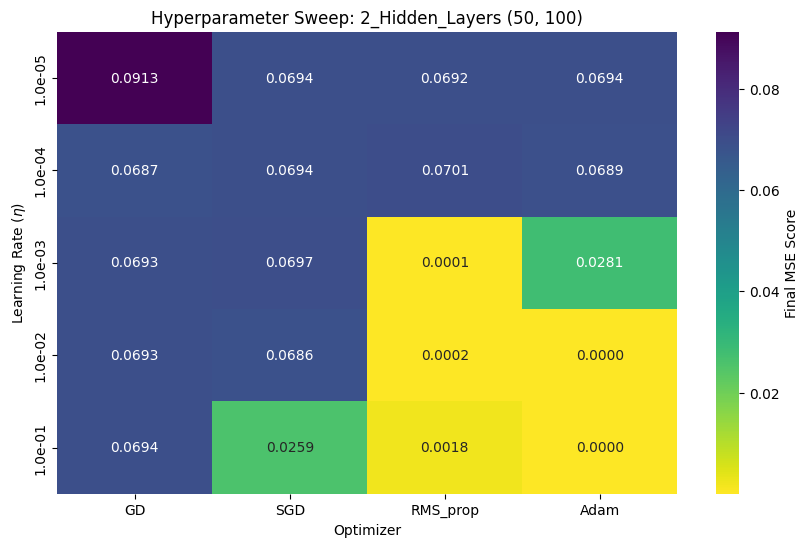

In [8]:
def plot_sweep_heatmap(sweep_data, eta_vals, title):
    """Generates a heatmap of final MSE scores."""
    
    df = pd.DataFrame(sweep_data, index=[f"{e:.1e}" for e in eta_vals]) # Rows: eta, Columns: Optimizers
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        df, 
        annot=True, 
        fmt=".4f", 
        cmap="viridis_r", 
        cbar_kws={'label': 'Final MSE Score'}
    )
    plt.title(f'Hyperparameter Sweep: {title}')
    plt.ylabel('Learning Rate ($\eta$)')
    plt.xlabel('Optimizer')
    plt.show()

# Generate heatmaps for each layer architecture
for arch_name, sweep_data in all_sweep_results.items():
    plot_sweep_heatmap(sweep_data, eta_vals, arch_name)

# Part c

In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

eta_val = 1e-1

mlp_regressor = MLPRegressor(
    # Architecture: Two hidden layers with 50 and 100 nodes
    hidden_layer_sizes=(hidden_nodes1, hidden_nodes2),
    # Hidden Layer Activation: Using sigmoid (common in sources)
    activation='logistic', # 'logistic' is the string for sigmoid in Scikit-learn
    # L2 Regularization parameter (alpha corresponds to lambda)
    alpha=lam,
    # Optimizer (e.g., Stochastic Gradient Descent)
    solver='sgd',
    # Initial Learning Rate
    learning_rate_init=eta_val,
    # Max Epochs
    max_iter=1000,
    # Ensure random state is set for reproducibility (matching seed=42 used earlier [15])
    random_state=42
)



In [10]:
mlp_regressor.fit(X_train_scaled, y_train.ravel())

y_pred_skl = mlp_regressor.predict(X_test_scaled)

skl_optimizers = {
    'SGD': 'sgd',
    'Adam': 'adam'
}

#hidden_layer_arch = layer_sizes_2H[:-1]
architectures_to_sweep = {
    '1_Hidden_Layer (50)': layer_sizes_1H,
    '2_Hidden_Layers (50, 100)': layer_sizes_2H
}
epochs_skl = 1000 # Use max_iter for Scikit-learn (e.g., 1000)

skl_sweep_results = {}

for arch_name, layer_sizes in architectures_to_sweep.items():
    hidden_layer_arch = layer_sizes[:-1]
    arch_scores = {}
    print(f"\n================ Starting SKL Sweep for Architecture: {arch_name} ================")

    # --- Optimizer Loop: Iterate through Solvers ('sgd', 'adam') ---
    for opt_name, solver_type in skl_optimizers.items():
        print(f"--- Running {opt_name} ---")
        mse_scores_for_eta = [] # List to store MSE for each eta value

        # --- Inner Loop: Iterate through Learning Rates (eta_vals) ---
        for eta in eta_vals:
            
            # 1. Initialize MLPRegressor model for the current combination
            skl_model = MLPRegressor(
                # Dynamically set the architecture based on the outer loop
                hidden_layer_sizes=hidden_layer_arch, 
                
                # Configuration matching the custom FFNN regression model:
                activation='logistic',       # Sigmoid activation [1]
                alpha=lam,                   # L2 regularization (lambda)
                solver=solver_type,          # Optimizer (sgd or adam)
                learning_rate_init=eta,      # Learning rate (eta)
                max_iter=epochs_skl,         # Max epochs
                random_state=42,             # For reproducibility [2]
            )

            # 2. Train the model
            # y_train is raveled to ensure Scikit-Learn compatibility for regression
            skl_model.fit(X_train_scaled, y_train.ravel()) 

            # 3. Evaluate on the test set
            y_pred_skl = skl_model.predict(X_test_scaled)
            final_mse = mean_squared_error(y_test, y_pred_skl)
            mse_scores_for_eta.append(final_mse)

            print(f"  {opt_name} (eta={eta:.1e}): Test MSE={final_mse:.6f}")

        # Store the list of scores for the current optimizer under the current architecture
        arch_scores[opt_name] = mse_scores_for_eta

    # Store all optimizer results for the current architecture
    skl_sweep_results[arch_name] = arch_scores
    
# Optional: Call plot_sweep_heatmap for visualization of results for each architecture
# (Assuming plot_sweep_heatmap is defined as discussed previously [3])
# for arch_name, sweep_data in skl_sweep_results.items():
#     plot_sweep_heatmap(sweep_data, eta_vals, arch_name)




================ Starting SKL Sweep for Architecture: 1_Hidden_Layer (50) ================
--- Running SGD ---
  SGD (eta=1.0e-05): Test MSE=0.123220
  SGD (eta=1.0e-04): Test MSE=0.070069
  SGD (eta=1.0e-03): Test MSE=0.077351
  SGD (eta=1.0e-02): Test MSE=0.071326
  SGD (eta=1.0e-01): Test MSE=0.223419
--- Running Adam ---
  Adam (eta=1.0e-05): Test MSE=0.169994
  Adam (eta=1.0e-04): Test MSE=0.069834
  Adam (eta=1.0e-03): Test MSE=0.079271
  Adam (eta=1.0e-02): Test MSE=0.068415
  Adam (eta=1.0e-01): Test MSE=0.109731

================ Starting SKL Sweep for Architecture: 2_Hidden_Layers (50, 100) ================
--- Running SGD ---
  SGD (eta=1.0e-05): Test MSE=0.092559
  SGD (eta=1.0e-04): Test MSE=0.068362
  SGD (eta=1.0e-03): Test MSE=0.078063
  SGD (eta=1.0e-02): Test MSE=0.069446
  SGD (eta=1.0e-01): Test MSE=0.068391
--- Running Adam ---
  Adam (eta=1.0e-05): Test MSE=0.081871
  Adam (eta=1.0e-04): Test MSE=0.069822
  Adam (eta=1.0e-03): Test MSE=0.068501
  Adam (eta=1.0e-0

<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/var/folders/yn/p45qg2hs32j6_2k0vv9s4kcw0000gn/T/ipykernel_17882/832802525.py:15: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Learning Rate ($\eta$)')


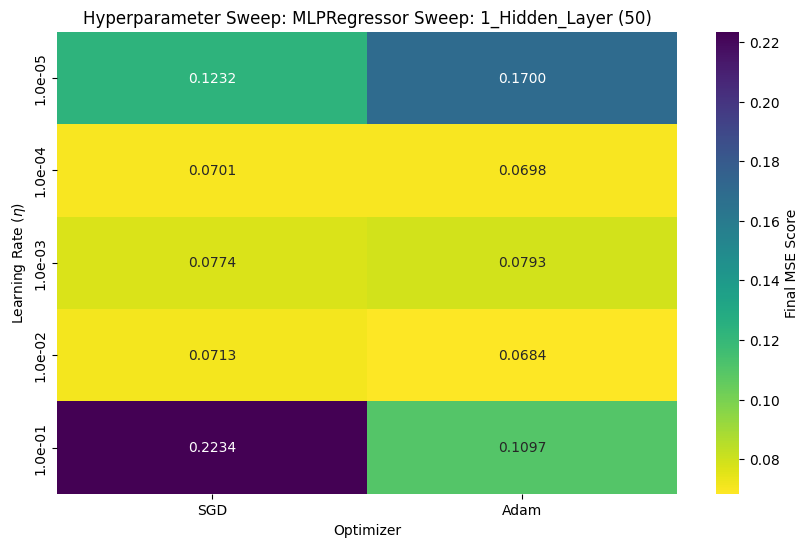

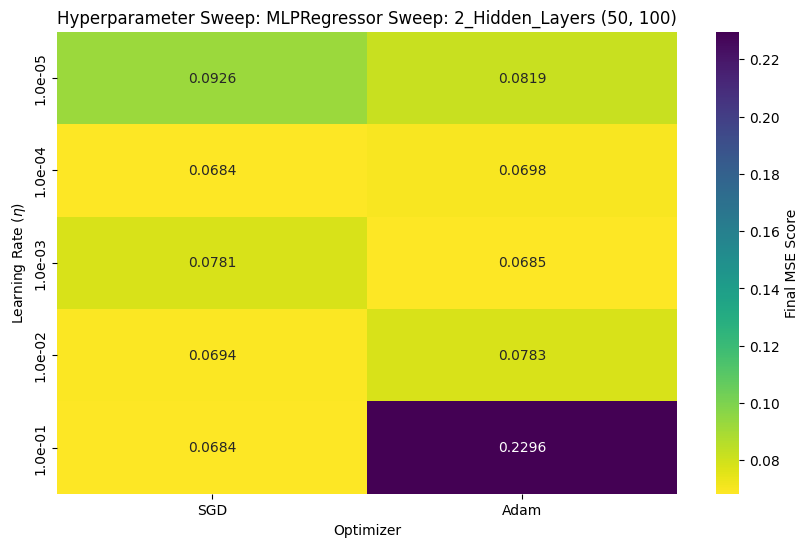

In [11]:
def plot_sweep_heatmap(sweep_data, eta_vals, title):
    """Generates a heatmap of final MSE scores."""
    # Rows: eta, Columns: Optimizers [9]
    df = pd.DataFrame(sweep_data, index=[f"{e:.1e}" for e in eta_vals]) 
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        df, 
        annot=True, 
        fmt=".4f", 
        cmap="viridis_r", # Reverse viridis often used for error visualization [9]
        cbar_kws={'label': 'Final MSE Score'}
    ) 
    plt.title(f'Hyperparameter Sweep: {title}')
    plt.ylabel('Learning Rate ($\eta$)')
    plt.xlabel('Optimizer')
    plt.show()

for arch_name, sweep_data in skl_sweep_results.items():
    # Pass the actual data for the current architecture (sweep_data)
    plot_sweep_heatmap(sweep_data, eta_vals, f"MLPRegressor Sweep: {arch_name}")


# Generate heatmap for Scikit-learn sweep results
#plot_sweep_heatmap(skl_sweep_results, eta_vals, 'Scikit-Learn MLPRegressor')



### Autograd check

In [12]:
#Recreate X_batch and t_batch from earlier for autograd check
batch_size_test = 25
n_test = X_test_scaled.shape[0] 
batch_size_test = min(batch_size_test, n_test)


start_index = np.random.randint(0, n_test - batch_size_test)
end_index = start_index + batch_size_test

X_batch = X_test_scaled[start_index:end_index]
t_batch = y_test[start_index:end_index]

manual_grads = nn.compute_gradient(X_batch, t_batch)

autograd_grads = nn.autograd_gradient(X_batch, t_batch)

for i in range(len(nn.layers)):
    # 1. Separate Weight gradients (index 0) and Bias gradients (index 1)
    manual_W_g, manual_b_g = manual_grads[i]
    autograd_W_g, autograd_b_g = autograd_grads[i]

    # 2. Compare the arrays individually using np.allclose
    weights_match = np.allclose(manual_W_g, autograd_W_g)
    biases_match = np.allclose(manual_b_g, autograd_b_g)

    print(f"Layer {i}: Weights match: {weights_match}, Biases match: {biases_match}")

print(X_batch.shape, t_batch.shape)
print("any NaN in X?", np.isnan(X_batch).any(), " any NaN in t?", np.isnan(t_batch).any())


Layer 0: Weights match: True, Biases match: True
Layer 1: Weights match: True, Biases match: True
Layer 2: Weights match: True, Biases match: True
(25, 1) (25, 1)
any NaN in X? False  any NaN in t? False


# Part d

In [13]:
from Code.activations import sigmoid, RELU, LRELU, identity, derivate
from Code.scheduler import Constant, RMS_prop, Adam

input_nodes = X_train_scaled.shape[1] # Features from scaled data
output_nodes = 1
layer_output_sizes_2H = [50, 100, output_nodes]
n_hidden_layers = len(layer_output_sizes_2H) - 1  # Should be 2 hidden layers
eta_constant = 0.01


# Define the activation functions to test for the hidden layers
activation_tests = {
    'Sigmoid': sigmoid,
    'RELU': RELU,
    'LRELU': LRELU
}


rho_val = 0.9
rho2_val = 0.999
batches = 25

optimizers_to_sweep = {
    'Constant': (Constant, {}),
    'RMS_prop': (RMS_prop, {'rho': rho_val}),
    'Adam': (Adam, {'rho': rho_val, 'rho2': rho2_val})
}

architectures_to_sweep = {
    '1_Hidden_Layer (50)': layer_sizes_1H,
    '2_Hidden_Layers (50, 100)': layer_sizes_2H
}



In [14]:
all_activation_results = {}
all_architectural_results = {}

# ======================= OUTER LOOP: ARCHITECTURE SWEEP =======================
for arch_name, layer_output_sizes in architectures_to_sweep.items():
    
    n_hidden_layers = len(layer_output_sizes) - 1
    all_activation_results = {}
    
    print(f"\n================ Starting Activation Sweep for {arch_name} ================")

    # Inner Loop 1: Iterate through Hidden Activation Functions
    for act_name, h_func in activation_tests.items():
        
        # 1. Construct the complete list of activation functions for this architecture
        activation_funcs = [h_func] * n_hidden_layers + [identity] 
        activation_ders = [derivate(f) for f in activation_funcs]
        
        current_act_scores = {}
        
        # Inner Loop 2: Iterate through Optimizers
        for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
            
            # Prepare kwargs, keeping eta constant
            current_kwargs = {'eta': eta_constant}
            current_kwargs.update(fixed_params)
            
            # 2. Initialize FFNN with the specific architecture and activation setup
            nn = FFNN(
                network_input_size=input_nodes,
                layer_output_sizes=tuple(layer_output_sizes),
                activation_funcs=activation_funcs,
                activation_ders=activation_ders,
                cost_fun=CostOLS,
                cost_der=dCostOLS,
                seed=42
            )
            nn.reset_weights() 
            
            # 3. Instantiate the scheduler (Optimizer)
            scheduler_instance = optimizer_class(**current_kwargs)

            # 4. Train the network
            scores = nn.fit(
                X_train_scaled, y_train, 
                scheduler=scheduler_instance, 
                batches=batches, 
                epochs=epochs_comparison, 
                lam=lam
            )
            
            # Log results
            final_mse = scores['train_errors'][-1]
            current_act_scores[opt_name] = final_mse
            print(f" {arch_name} | {act_name} + {opt_name}: MSE={final_mse:.6f}")

        all_activation_results[act_name] = current_act_scores

    all_architectural_results[arch_name] = all_activation_results
    for i, (W, b) in enumerate(nn.layers):
        print(f"Layer {i}: mean(W)={np.mean(W):.3e}, std(W)={np.std(W):.3e}")

    acts = nn._feed_forward_saver(X_train_scaled)[0]  # first hidden layer activations
    print("Fraction of zeros:", np.mean(acts == 0))




================ Starting Activation Sweep for 1_Hidden_Layer (50) ================
 1_Hidden_Layer (50) | Sigmoid + Constant: MSE=0.086155
 1_Hidden_Layer (50) | Sigmoid + RMS_prop: MSE=0.000987
 1_Hidden_Layer (50) | Sigmoid + Adam: MSE=0.000032
 1_Hidden_Layer (50) | RELU + Constant: MSE=0.000388
 1_Hidden_Layer (50) | RELU + RMS_prop: MSE=0.012525
 1_Hidden_Layer (50) | RELU + Adam: MSE=0.000074
 1_Hidden_Layer (50) | LRELU + Constant: MSE=0.000387
 1_Hidden_Layer (50) | LRELU + RMS_prop: MSE=0.006459
 1_Hidden_Layer (50) | LRELU + Adam: MSE=0.000045
Layer 0: mean(W)=-2.154e-01, std(W)=9.880e-01
Layer 1: mean(W)=4.132e-02, std(W)=1.933e-01
Fraction of zeros: 0.0

================ Starting Activation Sweep for 2_Hidden_Layers (50, 100) ================
 2_Hidden_Layers (50, 100) | Sigmoid + Constant: MSE=0.090671
 2_Hidden_Layers (50, 100) | Sigmoid + RMS_prop: MSE=0.000737
 2_Hidden_Layers (50, 100) | Sigmoid + Adam: MSE=0.000020
 2_Hidden_Layers (50, 100) | RELU + Constant: MSE=0

In [15]:
def plot_activation_sweep_heatmap(results_data, row_labels, title, eta_constant):
    # 1. Create DataFrame
    df = pd.DataFrame(results_data).T 
    
    # 2. **CRITICAL STEP: Create a NEW figure object**
    plt.figure(figsize=(10, 6)) 
    
    # 3. Draw Heatmap
    sns.heatmap(
        df, 
        annot=True, 
        fmt=".6f",
        cmap="viridis_r",
        cbar_kws={'label': 'Final MSE Score'}
    )
    
    # CORRECTED LINE: Removed the trailing subscript [1]
    plt.title(f'{title} (Fixed $\eta={eta_constant}$)') 
    
    plt.ylabel('Hidden Layer Activation Function')
    plt.xlabel('Optimizer')
    
    # 4. **Display the figure**
    plt.show()

    # (Optional, but recommended for sequential plotting)
    plt.close()

<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/var/folders/yn/p45qg2hs32j6_2k0vv9s4kcw0000gn/T/ipykernel_17882/1536594101.py:18: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'{title} (Fixed $\eta={eta_constant}$)')



--- Generating Heatmaps for All Architectures ---


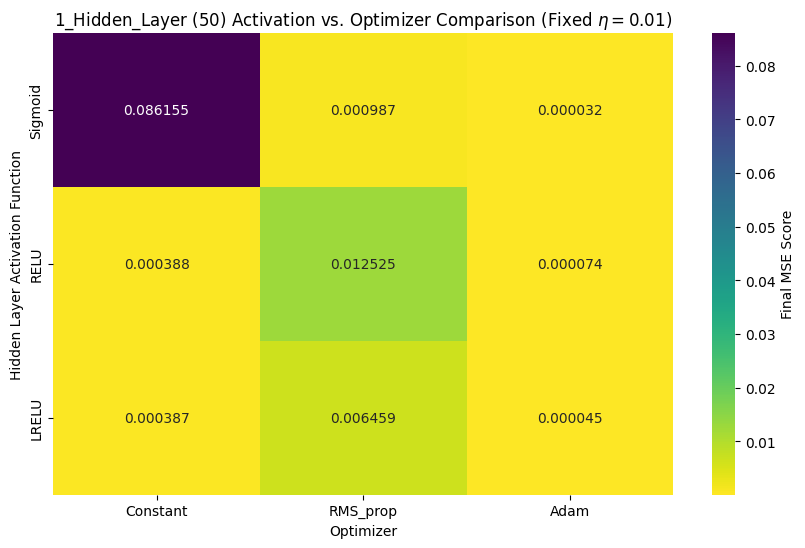

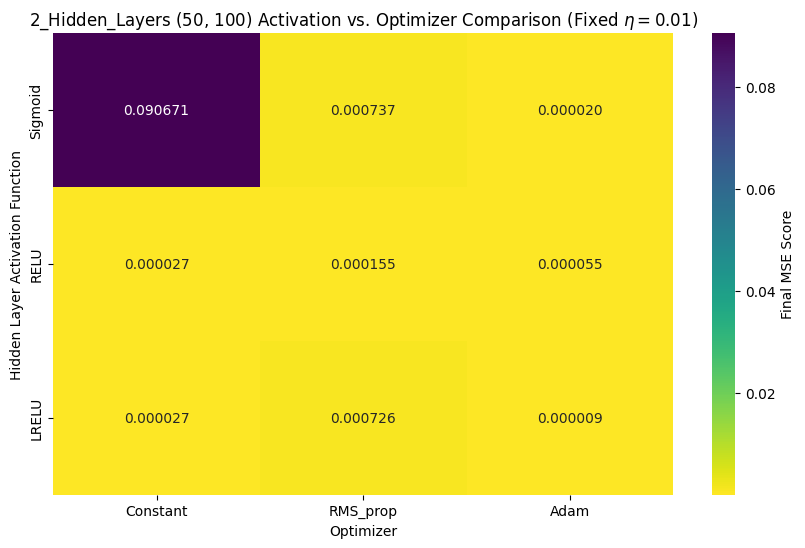

In [16]:
print("\n--- Generating Heatmaps for All Architectures ---")

activation_names = list(activation_tests.keys())

# Iterate over the comprehensive dictionary containing results for BOTH 1H and 2H
for arch_name, activation_scores in all_architectural_results.items():
    
    # activation_scores holds the data (Activation vs Optimizer MSE grid) for ONE architecture
    
    plot_activation_sweep_heatmap(
        results_data=activation_scores, 
        row_labels=activation_names, 
        title=f'{arch_name} Activation vs. Optimizer Comparison',
        eta_constant=eta_constant
    )


### As a function of layers and nodes: 

In [17]:
import autograd.numpy as np
from Code import activations as A
from Code.activations import identity, derivate

def resolve_activation(name: str):
    """
    Return (activation, derivative) for 'sigmoid', 'relu', 'lrelu' (leaky relu).
    Tries multiple attribute names in Code.activations; if missing, uses safe fallbacks.
    """
    n = name.strip().lower()

    # --- SIGMOID ---
    if n in ("sigmoid", "logistic"):
        f = getattr(A, "sigmoid", None)
        if f is None:
            # fallback (shouldn't be needed, but just in case)
            def f(z): return 1.0 / (1.0 + np.exp(-z))
        try:
            df = derivate(f)          # use your helper if available
        except Exception:
            def df(z):
                s = 1.0 / (1.0 + np.exp(-z))
                return s * (1 - s)
        return f, df

    # --- RELU ---
    if n in ("relu", "rectifier"):
        # try several common spellings/cases in your module
        for attr in ("relu", "ReLU", "Relu", "RELU"):
            f = getattr(A, attr, None)
            if f is not None:
                try:
                    return f, derivate(f)
                except Exception:
                    pass
        # fallback implementation
        def f(z): return np.maximum(0.0, z)
        def df(z): return (z > 0.0).astype(z.dtype)
        return f, df

    # --- LEAKY RELU / LRELU ---
    if n in ("lrelu", "leaky relu", "leaky_relu", "leakyrelu"):
        # try common names exported by your file
        for attr in ("lrelu", "leaky_relu", "LeakyReLU", "LReLU"):
            f = getattr(A, attr, None)
            if f is not None:
                try:
                    return f, derivate(f)
                except Exception:
                    pass
        # fallback implementation (alpha=0.01)
        alpha = 0.01
        def f(z): return np.where(z > 0.0, z, alpha * z)
        def df(z): return np.where(z > 0.0, 1.0, alpha)
        return f, df

    raise ValueError(f"Unknown activation '{name}'. Try: Sigmoid, ReLU, LReLU")


def run_grid(
    activations=("Sigmoid","ReLU","LReLU"),
    depths=(1,2),
    widths=(50,),
    optimizers=(("Adam", Adam, {"eta":1e-2,"rho":0.9,"rho2":0.999}),),
    *,
    epochs=500, batches=25, lam=0.0
):
    in_dim = X_train_scaled.shape[1]
    t_train = y_train.reshape(-1,1)

    results = {}
    for act_name in activations:
        hid_f, hid_df = resolve_activation(act_name)
        for d in depths:
            for w in widths:
                layer_sizes = [w]*d + [1]    # e.g. d=2,w=50 -> [50,50,1]
                activation_funcs = [hid_f]*d + [identity]
                activation_ders  = [hid_df]*d + [derivate(identity)]

                for opt_name, opt_cls, opt_kwargs in optimizers: 
                    clean_kwargs = {k: v for k, v in opt_kwargs.items() if k in ("eta","rho","rho2")}
                    mse_hist, nn = run_comparison(
                        opt_cls,
                        X_train=X_train_scaled,
                        t_train=t_train,
                        network_input_size=in_dim,
                        layer_output_sizes=layer_sizes,
                        activation_funcs=activation_funcs,
                        activation_ders=activation_ders,
                        epochs=epochs, batches=batches, lam=lam,
                        **clean_kwargs
                    )
                    results[(act_name, d, w, opt_name)] = (mse_hist, nn)
    return results


# Helper to evaluate model performance
def eval_model(nn):
    ytr = y_train.reshape(-1,1); yte = y_test.reshape(-1,1) 
    tr = np.mean((nn.predict(X_train_scaled)-ytr)**2) # Train MSE
    te = np.mean((nn.predict(X_test_scaled)-yte)**2) # Test MSE
    return tr, te, te - tr


In [18]:
activation = ("LReLU",)
optimizers = (
    ("Adam", Adam, {"eta":1e-2, "rho":0.9, "rho2":0.999}),
)
depths = (0,1,2,3)          # hidden-layer counts
widths = (5,10,25,50)       # nodes per layer

results = run_grid(
    activations=activation,     # fix one activation, e.g. ReLU
    depths=depths,          # hidden-layer counts
    widths=widths,       # nodes per layer
    optimizers=optimizers,
    epochs=500, batches=25, lam=0.0
)

# make a tiny table for one activation & optimizer
act, opt = "LReLU", "Adam"
rows = []
for (a,d,w,o), (hist, nn) in results.items():
    if a==act and o==opt:
        tr, te, gap = eval_model(nn)
        rows.append((d, w, te, gap))
rows = sorted(rows)  # by depth then width
for d,w,te,gap in rows:
    print(f"{act} | {opt} | depth={d:>1} width={w:>3} -> test MSE={te:.6f}, gap={gap:.6f}")


LReLU | Adam | depth=0 width=  5 -> test MSE=0.069065, gap=-0.016954
LReLU | Adam | depth=0 width= 10 -> test MSE=0.069065, gap=-0.016954
LReLU | Adam | depth=0 width= 25 -> test MSE=0.069065, gap=-0.016954
LReLU | Adam | depth=0 width= 50 -> test MSE=0.069065, gap=-0.016954
LReLU | Adam | depth=1 width=  5 -> test MSE=0.000792, gap=0.000158
LReLU | Adam | depth=1 width= 10 -> test MSE=0.000098, gap=-0.000005
LReLU | Adam | depth=1 width= 25 -> test MSE=0.000017, gap=-0.000006
LReLU | Adam | depth=1 width= 50 -> test MSE=0.000463, gap=-0.000060
LReLU | Adam | depth=2 width=  5 -> test MSE=0.000018, gap=-0.000011
LReLU | Adam | depth=2 width= 10 -> test MSE=0.000015, gap=0.000002
LReLU | Adam | depth=2 width= 25 -> test MSE=0.000031, gap=0.000005
LReLU | Adam | depth=2 width= 50 -> test MSE=0.000004, gap=0.000002
LReLU | Adam | depth=3 width=  5 -> test MSE=0.000025, gap=0.000008
LReLU | Adam | depth=3 width= 10 -> test MSE=0.000064, gap=0.000010
LReLU | Adam | depth=3 width= 25 -> test

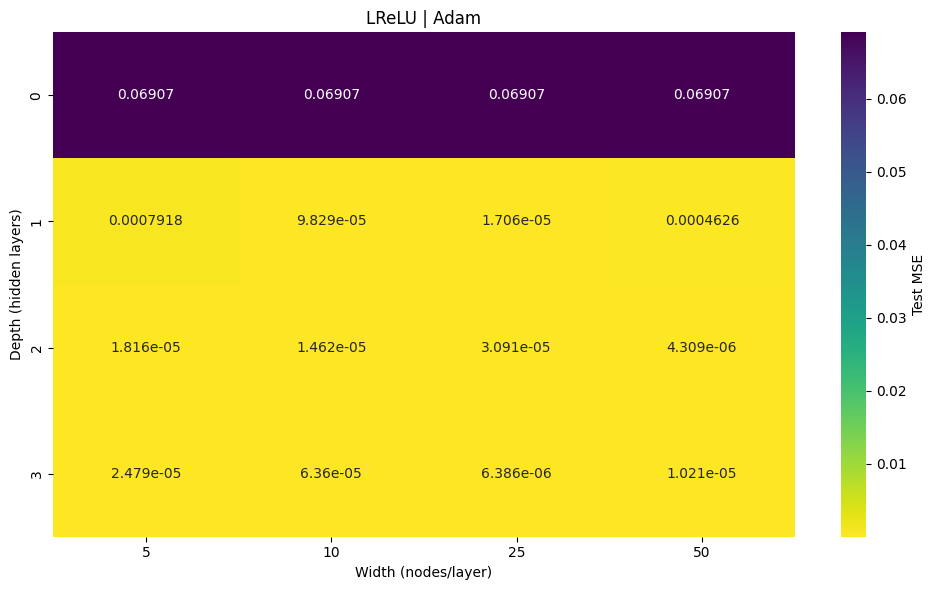

In [19]:
def heatmap_depth_width_sns(rows, depths, widths, metric="mse", title=None, vmin=None, vmax=None, log=False):
    import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm

    df = pd.DataFrame(index=depths, columns=widths, dtype=float)
    for d, w, te, gap in rows:
        df.loc[d, w] = te if metric=="mse" else gap

    plt.figure(figsize=(10, 6))
    norm = LogNorm(vmin=max(df.min().min(), 1e-12), vmax=df.max().max()) if log else None
    sns.heatmap(
        df, annot=True, fmt=".4g",
        cmap="viridis_r",         # <-- yellow small, purple large
        vmin=vmin, vmax=vmax,     # set these for consistent scaling across plots (optional)
        norm=norm,
        cbar_kws={'label': "Test MSE" if metric=="mse" else "Generalization gap"}
    )
    plt.ylabel("Depth (hidden layers)")
    plt.xlabel("Width (nodes/layer)")
    if title: plt.title(title)
    plt.tight_layout(); plt.show()


heatmap_depth_width_sns(rows, depths, widths, metric="mse", title=f"{act} | {opt}")



# Part e

In [23]:
lam_vals = np.logspace(-5, 2, 8) 


L2_sweep_results = {}

print("\n\n================ Starting L2 (Ridge) Regularization Sweep ================")

for arch_name, layer_sizes in architectures_to_sweep.items():
    arch_scores = {}
    print(f"\n---- Sweep for {arch_name} ----")
    
    for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
        print(f"--- Optimizer {opt_name} ---")
        
        # Store results for this optimizer across all eta and lambda values
        optimizer_results_grid = np.zeros((len(eta_vals), len(lam_vals)))

        for i, eta in enumerate(eta_vals):
            for j, lam in enumerate(lam_vals): # New loop for lambda
                
                # Prepare kwargs for the current run
                current_kwargs = {'eta': eta}
                current_kwargs.update(fixed_params)
                
                # Run comparison with L2 regularization (lam parameter)
                scores, nn = run_comparison(
                    optimizer_class, 
                    X_train_scaled, 
                    y_train, 
                    network_input_size=input_nodes, 
                    layer_output_sizes=layer_sizes, 
                    epochs=epochs_sweep, 
                    l2=lam, # Pass regularization parameter
                    **current_kwargs
                )
                
                y_pred_test = nn.predict(X_test_scaled)
                final_mse = CostOLS(y_pred_test, y_test)
                
                optimizer_results_grid[i, j] = final_mse
                print(f"  {opt_name} (eta={eta:.1e}, lam={lam:.1e}): MSE={final_mse:.6f}")
        
        arch_scores[opt_name] = optimizer_results_grid

    L2_sweep_results[arch_name] = arch_scores



================ Starting L2 (Ridge) Regularization Sweep ================

---- Sweep for 1_Hidden_Layer (50) ----
--- Optimizer Constant ---
  Constant (eta=1.0e-05, lam=1.0e-05): MSE=0.069618
  Constant (eta=1.0e-05, lam=1.0e-04): MSE=0.069618
  Constant (eta=1.0e-05, lam=1.0e-03): MSE=0.069617
  Constant (eta=1.0e-05, lam=1.0e-02): MSE=0.069610
  Constant (eta=1.0e-05, lam=1.0e-01): MSE=0.069538
  Constant (eta=1.0e-05, lam=1.0e+00): MSE=0.068980
  Constant (eta=1.0e-05, lam=1.0e+01): MSE=0.070074
  Constant (eta=1.0e-05, lam=1.0e+02): MSE=0.092482
  Constant (eta=1.0e-04, lam=1.0e-05): MSE=0.069443
  Constant (eta=1.0e-04, lam=1.0e-04): MSE=0.069443
  Constant (eta=1.0e-04, lam=1.0e-03): MSE=0.069441
  Constant (eta=1.0e-04, lam=1.0e-02): MSE=0.069425
  Constant (eta=1.0e-04, lam=1.0e-01): MSE=0.069287
  Constant (eta=1.0e-04, lam=1.0e+00): MSE=0.068819
  Constant (eta=1.0e-04, lam=1.0e+01): MSE=0.068405
  Constant (eta=1.0e-04, lam=1.0e+02): MSE=0.068348
  Constant (eta=1.0e-03

/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/.venv/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:53: RuntimeWarning: overflow encountered in square
  lambda ans, x, y : unbroadcast_f(y, lambda g: - g * x / y**2))
/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/.venv/lib/python3.12/site-packages/autograd/tracer.py:48: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)
/Users/selmabeateovland/Documents/Fys-stk4155/Project2/Project_2/.venv/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:75: RuntimeWarning: invalid value encountered in multiply
  defvjp(anp.exp,    lambda ans, x : lambda g: ans * g)


  Constant (eta=1.0e-01, lam=1.0e+02): MSE=nan
--- Optimizer RMS_prop ---
  RMS_prop (eta=1.0e-05, lam=1.0e-05): MSE=0.069022
  RMS_prop (eta=1.0e-05, lam=1.0e-04): MSE=0.069022
  RMS_prop (eta=1.0e-05, lam=1.0e-03): MSE=0.069024
  RMS_prop (eta=1.0e-05, lam=1.0e-02): MSE=0.069034
  RMS_prop (eta=1.0e-05, lam=1.0e-01): MSE=0.068982
  RMS_prop (eta=1.0e-05, lam=1.0e+00): MSE=0.068511
  RMS_prop (eta=1.0e-05, lam=1.0e+01): MSE=0.070552
  RMS_prop (eta=1.0e-05, lam=1.0e+02): MSE=0.078377
  RMS_prop (eta=1.0e-04, lam=1.0e-05): MSE=0.069078
  RMS_prop (eta=1.0e-04, lam=1.0e-04): MSE=0.069084
  RMS_prop (eta=1.0e-04, lam=1.0e-03): MSE=0.069126
  RMS_prop (eta=1.0e-04, lam=1.0e-02): MSE=0.069201
  RMS_prop (eta=1.0e-04, lam=1.0e-01): MSE=0.069083
  RMS_prop (eta=1.0e-04, lam=1.0e+00): MSE=0.068743
  RMS_prop (eta=1.0e-04, lam=1.0e+01): MSE=0.068695
  RMS_prop (eta=1.0e-04, lam=1.0e+02): MSE=0.069232
  RMS_prop (eta=1.0e-03, lam=1.0e-05): MSE=0.015960
  RMS_prop (eta=1.0e-03, lam=1.0e-04): MSE

In [21]:
l1_vals = np.logspace(-5, 0, 6)
L1_sweep_results = {}
print("\n\n================ Starting L1 (Lasso) Regularization Sweep ================")

for arch_name, layer_sizes in architectures_to_sweep.items():
    arch_scores = {}
    print(f"\n---- Sweep for {arch_name} ----")
    for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
        print(f"--- Optimizer {opt_name} ---")
        optimizer_results_grid = np.zeros((len(eta_vals), len(l1_vals)))
        for i, eta in enumerate(eta_vals):
            for j, l1_ in enumerate(l1_vals):
                current_kwargs = {'eta': eta}
                current_kwargs.update(fixed_params)
                scores, nn = run_comparison(
                    optimizer_class,
                    X_train_scaled, y_train,
                    network_input_size=input_nodes,
                    layer_output_sizes=layer_sizes,
                    epochs=epochs_sweep,
                    l1=l1_,     # <--- NEW: L1 penalty
                    l2=0.0,     # keep L2 off in this sweep
                    **current_kwargs
                )
                y_pred_test = nn.predict(X_test_scaled)
                final_mse = CostOLS(y_pred_test, y_test)
                optimizer_results_grid[i, j] = final_mse
                print(f" {opt_name} (eta={eta:.1e}, l1={l1_:.1e}): MSE={final_mse:.6f}")
        arch_scores[opt_name] = optimizer_results_grid
    L1_sweep_results[arch_name] = arch_scores




================ Starting L1 (Lasso) Regularization Sweep ================

---- Sweep for 1_Hidden_Layer (50) ----
--- Optimizer Constant ---
 Constant (eta=1.0e-05, l1=1.0e-05): MSE=0.069618
 Constant (eta=1.0e-05, l1=1.0e-04): MSE=0.069618
 Constant (eta=1.0e-05, l1=1.0e-03): MSE=0.069612
 Constant (eta=1.0e-05, l1=1.0e-02): MSE=0.069550
 Constant (eta=1.0e-05, l1=1.0e-01): MSE=0.069012
 Constant (eta=1.0e-05, l1=1.0e+00): MSE=0.073253
 Constant (eta=1.0e-04, l1=1.0e-05): MSE=0.069443
 Constant (eta=1.0e-04, l1=1.0e-04): MSE=0.069441
 Constant (eta=1.0e-04, l1=1.0e-03): MSE=0.069424
 Constant (eta=1.0e-04, l1=1.0e-02): MSE=0.069283
 Constant (eta=1.0e-04, l1=1.0e-01): MSE=0.068591
 Constant (eta=1.0e-04, l1=1.0e+00): MSE=0.068338
 Constant (eta=1.0e-03, l1=1.0e-05): MSE=0.069209
 Constant (eta=1.0e-03, l1=1.0e-04): MSE=0.069211
 Constant (eta=1.0e-03, l1=1.0e-03): MSE=0.069242
 Constant (eta=1.0e-03, l1=1.0e-02): MSE=0.069349
 Constant (eta=1.0e-03, l1=1.0e-01): MSE=0.069334
 Cons

In [27]:
def l2_norm(nn):
    return sum(np.linalg.norm(W)**2 for W,_ in nn.layers)

_, nn_small = run_comparison(Adam, X_train_scaled, y_train,
                             network_input_size=input_nodes, layer_output_sizes=[50,1],
                             epochs=300, batches=25, eta=1e-3, rho=0.9, rho2=0.999, l2=0.0)
_, nn_large = run_comparison(Adam, X_train_scaled, y_train,
                             network_input_size=input_nodes, layer_output_sizes=[50,1],
                             epochs=300, batches=25, eta=1e-3, rho=0.9, rho2=0.999, l2=1.0)
print("||W||² (no reg):", l2_norm(nn_small))
print("||W||² (λ=1):",   l2_norm(nn_large))


||W||² (no reg): 3.4824321826895783
||W||² (λ=1): 0.0020568956434072424


In [28]:
def capacity_sweep(build_nn_maker, optimizer_cls, opt_kwargs,
                   X_train, y_train, X_test, y_test,
                   depths=(0,1,2,3), widths=(5,10,25,50),
                   epochs=400, batches=25, lam=0.0, l1=0.0, l2=0.0):
    results = {}  # (depth,width) -> (train_mse, test_mse)
    for d in depths:
        for w in widths:
            nn = build_nn_maker(depth=d, width=w, l1=l1, l2=l2)
            sched = optimizer_cls(**opt_kwargs)

            # simple training loop
            N = X_train.shape[0]
            for e in range(epochs):
                idx = np.random.permutation(N)
                Xs, ys = X_train[idx], y_train[idx]
                bs = max(1, N // batches)
                for i in range(batches):
                    s = i*bs
                    t = (i+1)*bs if i < batches-1 else N
                    Xb, yb = Xs[s:t], ys[s:t]
                    grads = nn.compute_gradient(Xb, yb)
                    nn.update_weights(grads, learning_rate=opt_kwargs.get("eta", 1e-2))

            tr = float(np.mean((nn.predict(X_train)-y_train)**2))
            te = float(np.mean((nn.predict(X_test)-y_test)**2))
            results[(d,w)] = (tr, te)
    return results
